# Thư viện

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import KNeighborsClassifier
from skimage.metrics import structural_similarity as ssim
from scipy.stats import kstest, ks_2samp
import cv2

In [2]:
utils_path = os.path.abspath(os.path.join(os.getcwd(), "../..", "src"))

if utils_path not in sys.path:
    sys.path.append(utils_path)

from utils import *
from augmentation import AugmentationPipeline

In [3]:
CSV_PATH = "../../data/Image/labels_remove_duplicate.csv"

IMAGES_PATH = "../../data/Image/images_remove_duplicate"

PIXEL_RANGE = 256
SAMPLE_SIZE = 50

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

# Load data

In [4]:
data = pd.read_csv(CSV_PATH)
data = data.drop("original_image", axis=1)
labels = [label for label in data["label"].unique()]

In [5]:
n_images = 0

all_images = []

images = {label: [] for label in labels}

for row in data.itertuples(index=False):
    img_name = row[0]
    img_label = row[1]
    img_path = os.path.join(IMAGES_PATH, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_COLOR)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    images[img_label].append(img)

    all_images.append(img)
    n_images += 1

for label in labels:
    images[label] = np.array(images[label])

all_images = np.array(all_images)

# Các kỹ thuật tiền xử lý và phân tích tác động

## Thay đổi kích thước và chất lượng ảnh

Với tập dữ liệu (5000, 256, 256, 3), tổng số pixel cần xử lý là 500 x 256 x 256 = 327_680_000 (327 triệu). Phân tích độ sáng trên toàn tập dữ liệu là không khả thi, do đó thực hiện việc lấy mẫu và chuyển đổi về ảnh xám như sau:

Lấy 50 mẫu mỗi class, kích thước tập mẫu là (250, 256, 256, 3), sau đó chuyển đổi ảnh RGB thành ảnh xám theo công thức:

g = 0.299 * r + 0.587 * g + 0.114 * b

Tổng số pixel cần xử lý là 16_384_000 x 1 kênh màu.

In [6]:
sample_gray = dict()

for label in labels:
    sample_id = np.random.randint(0, len(images[label]), size=SAMPLE_SIZE)
    sample = images[label][sample_id]
    sample_gray[label] = convert_rgb_to_color_space(sample, "gray")

In [7]:
size_list = [128, 64, 32, 16]

In [8]:
images_128 = {label: [] for label in labels}
images_64 = {label: [] for label in labels}
images_32 = {label: [] for label in labels}
images_16 = {label: [] for label in labels}

images_128_u = {label: [] for label in labels}
images_64_u = {label: [] for label in labels}
images_32_u = {label: [] for label in labels}
images_16_u = {label: [] for label in labels}

for label in labels:
    for image in sample_gray[label]:
        # downscale
        resize_128 = cv2.resize(image, (size_list[0], size_list[0]), interpolation=cv2.INTER_AREA)
        resize_64 = cv2.resize(image, (size_list[1], size_list[1]), interpolation=cv2.INTER_AREA)
        resize_32 = cv2.resize(image, (size_list[2], size_list[2]), interpolation=cv2.INTER_AREA)
        resize_16 = cv2.resize(image, (size_list[3], size_list[3]), interpolation=cv2.INTER_AREA)

        # upscale cho SSIM
        resize_128_u = cv2.resize(resize_128, (256, 256), interpolation=cv2.INTER_AREA)
        resize_64_u = cv2.resize(resize_64, (256, 256), interpolation=cv2.INTER_AREA)
        resize_32_u = cv2.resize(resize_32, (256, 256), interpolation=cv2.INTER_AREA)
        resize_16_u = cv2.resize(resize_16, (256, 256), interpolation=cv2.INTER_AREA)

        images_128[label].append(resize_128)
        images_64[label].append(resize_64)
        images_32[label].append(resize_32)
        images_16[label].append(resize_16)

        images_128_u[label].append(resize_128_u)
        images_64_u[label].append(resize_64_u)
        images_32_u[label].append(resize_32_u)
        images_16_u[label].append(resize_16_u)

    images_128[label] = np.array(images_128[label])
    images_64[label] = np.array(images_64[label])
    images_32[label] = np.array(images_32[label])
    images_16[label] = np.array(images_16[label])

    images_128_u[label] = np.array(images_128_u[label])
    images_64_u[label] = np.array(images_64_u[label])
    images_32_u[label] = np.array(images_32_u[label])
    images_16_u[label] = np.array(images_16_u[label])

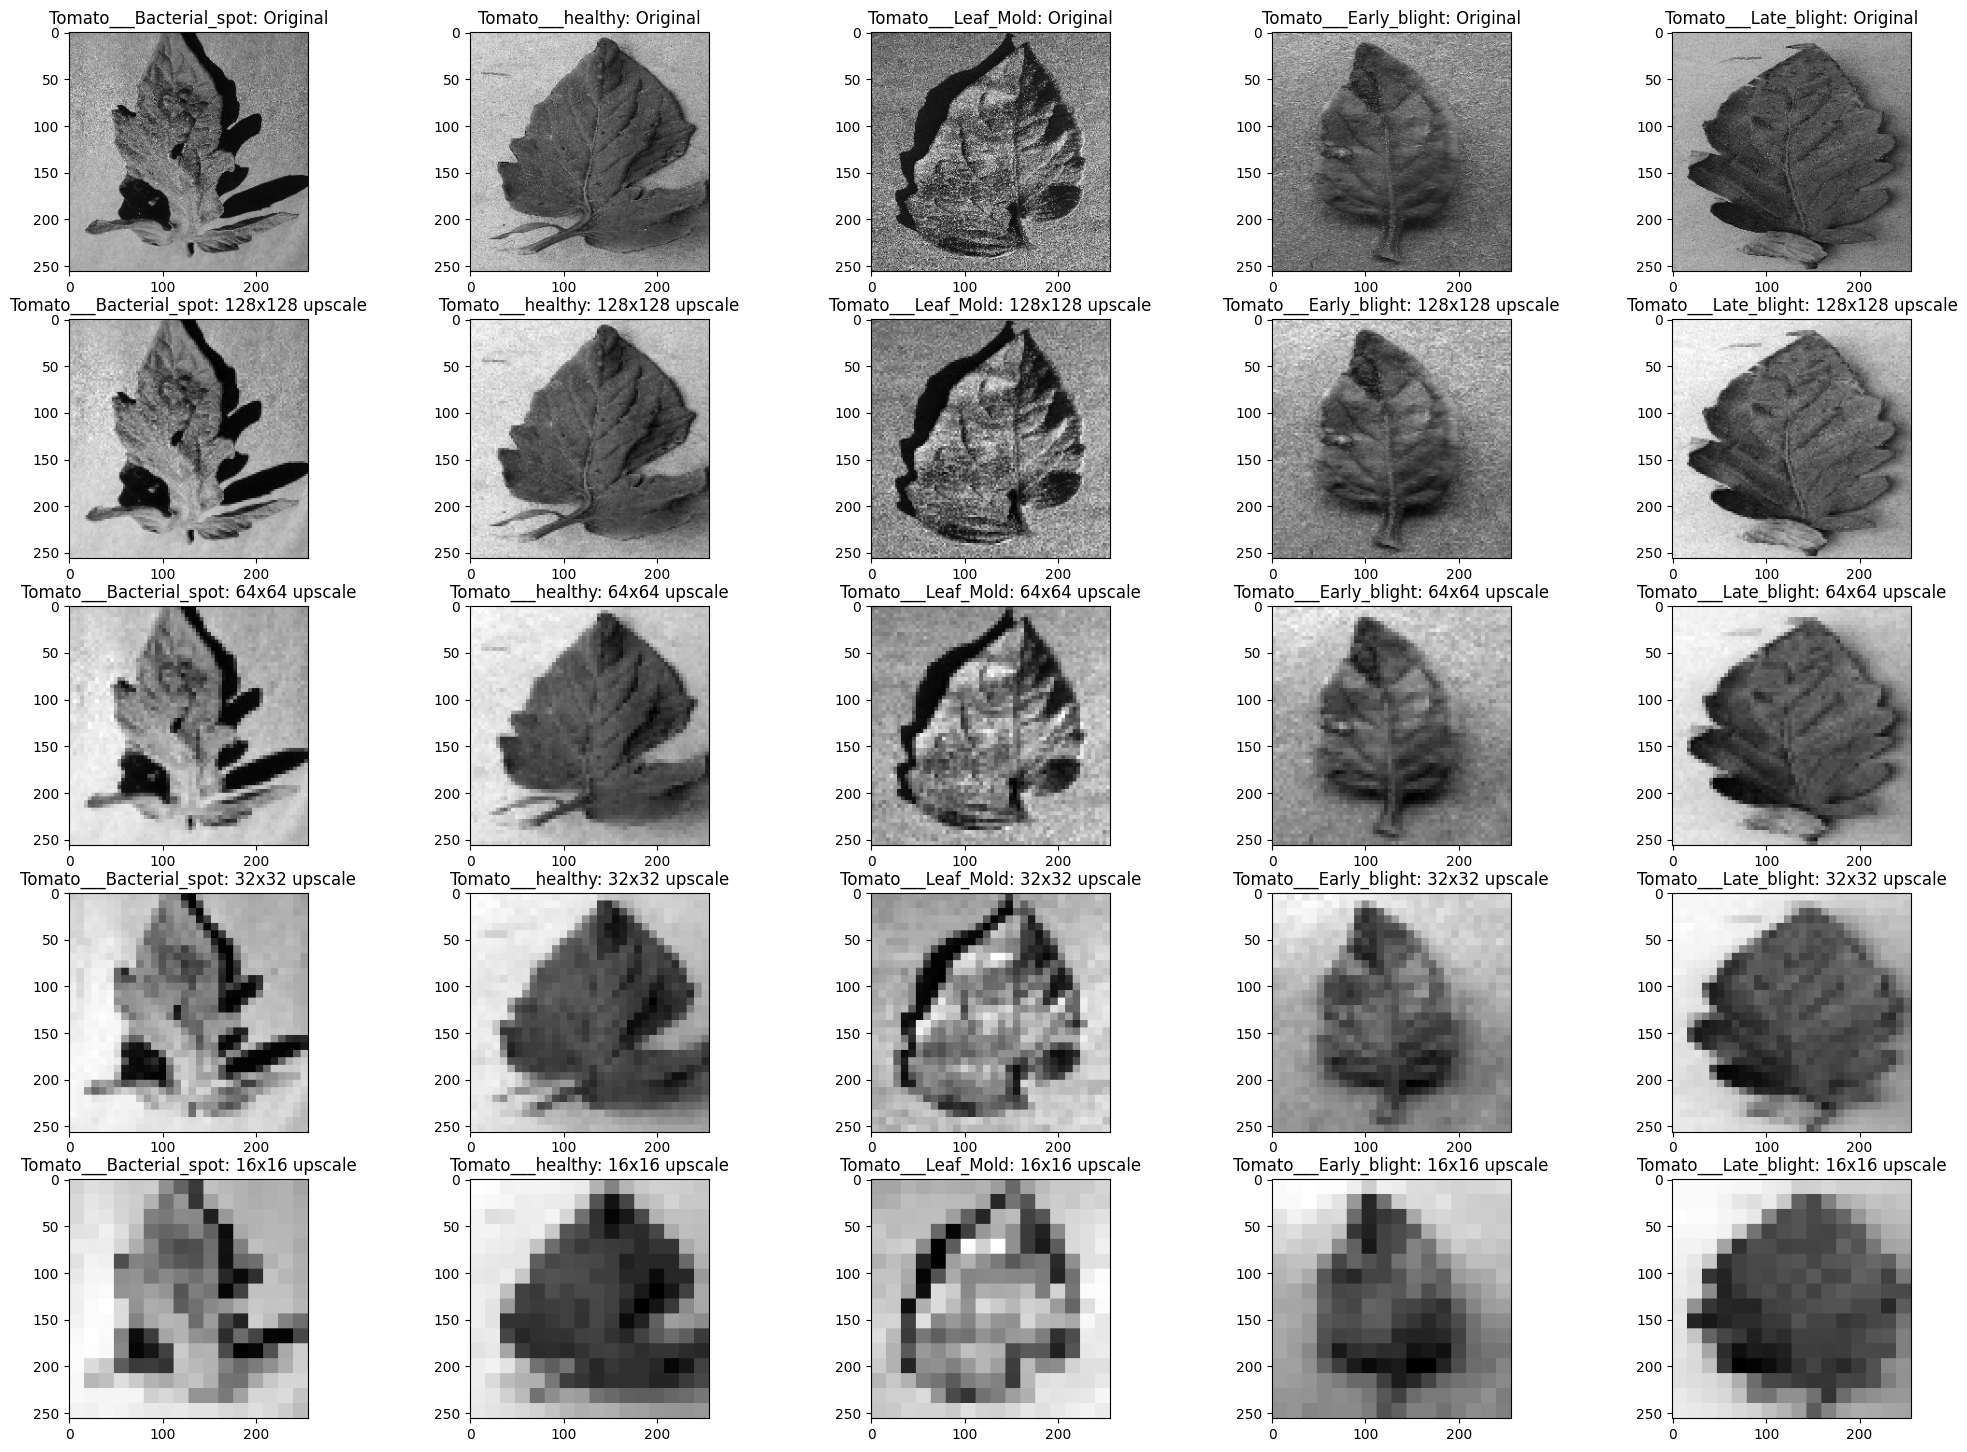

In [9]:
fig, ax = plt.subplots(5, 5, figsize=(25, 18))

for index, label in enumerate(labels):
    ax[0][index].imshow(sample_gray[label][0], cmap="gray")
    ax[0][index].set_title(f"{label}: Original")

    ax[1][index].imshow(images_128_u[label][0], cmap="gray")
    ax[1][index].set_title(f"{label}: 128x128 upscale")

    ax[2][index].imshow(images_64_u[label][0], cmap="gray")
    ax[2][index].set_title(f"{label}: 64x64 upscale")

    ax[3][index].imshow(images_32_u[label][0], cmap="gray")
    ax[3][index].set_title(f"{label}: 32x32 upscale")

    ax[4][index].imshow(images_16_u[label][0], cmap="gray")
    ax[4][index].set_title(f"{label}: 16x16 upscale")

### SSIM

In [10]:
score = {label: [[] for _ in range(len(size_list))] for label in labels}

for label in labels:
    for i in range(len(sample_gray[label])):
        _score, _ = ssim(sample_gray[label][i], images_128_u[label][i], full=True)
        score[label][0].append(_score)

        _score, _ = ssim(sample_gray[label][i], images_64_u[label][i], full=True)
        score[label][1].append(_score)

        _score, _ = ssim(sample_gray[label][i], images_32_u[label][i], full=True)
        score[label][2].append(_score)

        _score, _ = ssim(sample_gray[label][i], images_16_u[label][i], full=True)
        score[label][3].append(_score)

    score[label] = np.mean(score[label], axis=1)
    score[label] = np.concatenate(([1], score[label]), axis=0)

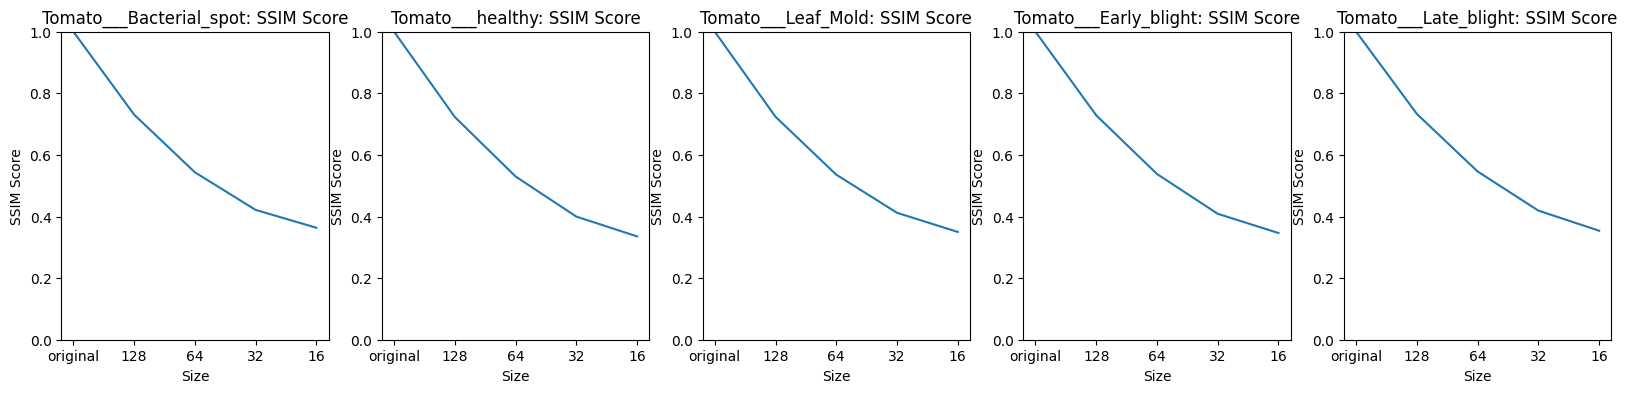

In [11]:
fig, ax = plt.subplots(1, len(labels), figsize=(20, 4))

for index, label in enumerate(labels):
    ax[index].plot(score[label])
    ax[index].set_ylim(0, 1)
    ax[index].set_title(f"{label}: SSIM Score")
    ax[index].set_xticks(range(len(size_list) + 1), ["original"] + size_list)
    ax[index].set_xlabel("Size")
    ax[index].set_ylabel("SSIM Score")

Lựa chọn resize về kích thước 128 x 128 vì chỉ số thông tin trung bình chỉ giảm khoảng 20% nhưng kích thước dữ liệu có thể giảm 4 lần

### PSNR

In [12]:
score = {label: [[] for _ in range(len(size_list))] for label in labels}

for label in labels:
    for i in range(len(sample_gray[label])):
        _score = calculate_psnr(sample_gray[label][i], images_128_u[label][i])
        score[label][0].append(_score)

        _score = calculate_psnr(sample_gray[label][i], images_64_u[label][i])
        score[label][1].append(_score)

        _score = calculate_psnr(sample_gray[label][i], images_32_u[label][i],)
        score[label][2].append(_score)

        _score = calculate_psnr(sample_gray[label][i], images_16_u[label][i])
        score[label][3].append(_score)

    score[label] = np.mean(score[label], axis=1)
    score[label] = np.concatenate(([float("inf")], score[label]), axis=0)

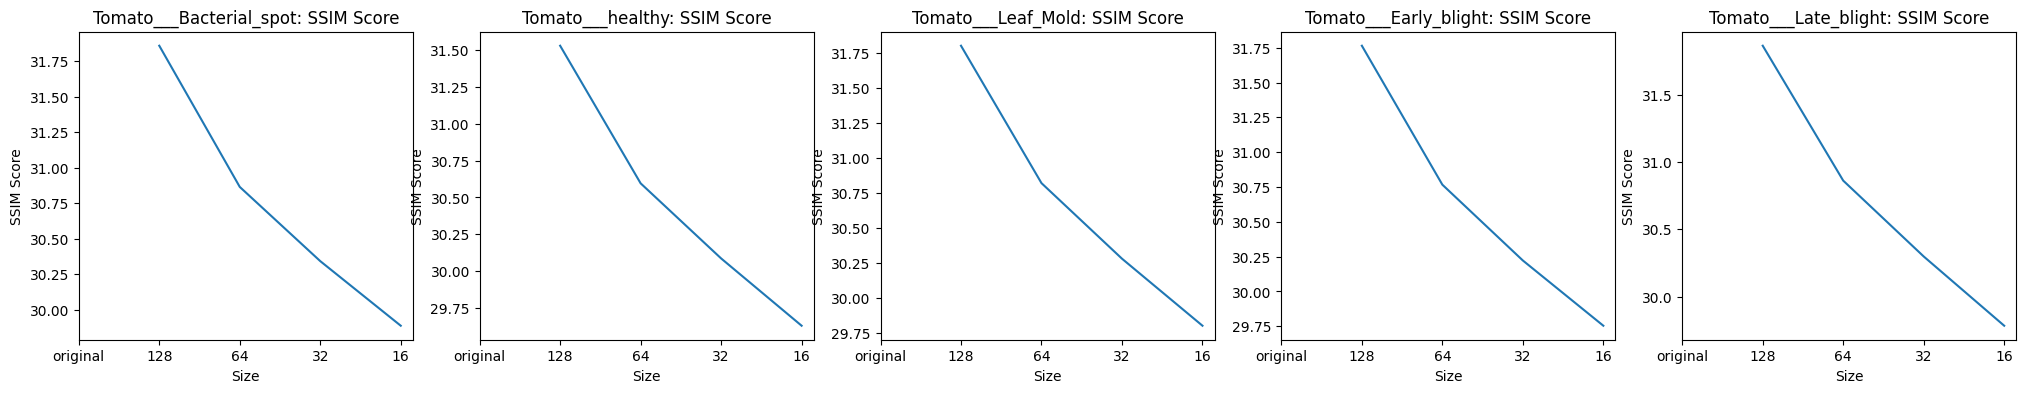

In [13]:
fig, ax = plt.subplots(1, len(labels), figsize=(25, 4))

for index, label in enumerate(labels):
    ax[index].plot(score[label])
    ax[index].set_title(f"{label}: SSIM Score")
    ax[index].set_xticks(range(len(size_list) + 1), ["original"] + size_list)
    ax[index].set_xlabel("Size")
    ax[index].set_ylabel("SSIM Score")

In [ ]:
del sample_gray

del resize_128
del resize_64
del resize_32
del resize_16

del resize_128_u
del resize_64_u
del resize_32_u
del resize_16_u

del images_128
del images_64
del images_32
del images_16

del images_128_u
del images_64_u
del images_32_u
del images_16_u

## Chuyển đổi không gian màu

In [ ]:
color_space = ["RGB", "HSV", "LAB", "gray"]

In [6]:
sample_all = np.empty((SAMPLE_SIZE * len(labels), 256, 256, 3), dtype=np.uint8)

start = 0
for label in labels:
    sample_id = np.random.randint(0, len(images[label]), size=SAMPLE_SIZE)
    sample_all[start:start + SAMPLE_SIZE] = images[label][sample_id]
    start += SAMPLE_SIZE

In [ ]:
explained_variance = dict()

for space in color_space:
    explained_variance[space] = calculate_explained_variance(convert_rgb_to_color_space(sample_all, space))

RGB
HSV
LAB
gray


Text(0.5, 1.0, 'Explained Variance')

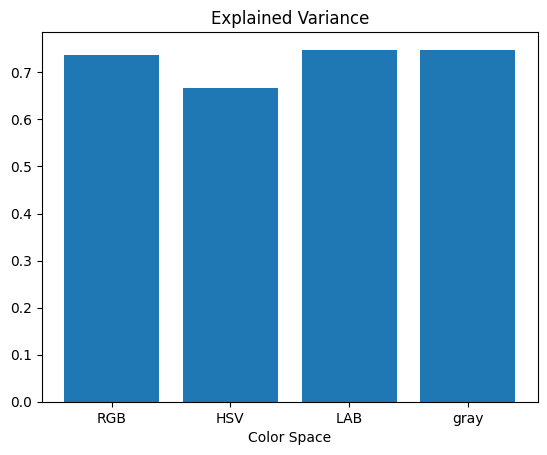

In [ ]:
# fig, ax = plt.subplots(1, len(color_space), figsize=(20, 4))

plt.bar(explained_variance.keys(), explained_variance.values())
plt.xlabel("Color Space")
plt.title("Explained Variance")

In [ ]:
del sample_all

Cả 4 không gian màu đều có phương sai giải thích tương đồng (~ 0.65), trong đó không gian ảnh xám chỉ có 1 kênh màu nhưng có giá trị thống kê tương đương các không gian khác. Do đó lựa chọn đưa về ảnh xám giúp giảm kích thước dữ liệu đi 3 lần.

## Chuẩn hoá

In [ ]:
sample_all = np.empty((SAMPLE_SIZE * len(labels), 256, 256, 3), dtype=np.uint8)

start = 0
for label in labels:
    sample_id = np.random.randint(0, len(images[label]), size=SAMPLE_SIZE)
    sample_all[start:start + SAMPLE_SIZE] = images[label][sample_id]
    start += SAMPLE_SIZE

In [13]:
from scipy.stats import ks_2samp, kstest

normalize_func = [normalize_min_max, normalize_min_max_, z_score_all_channel, z_score_per_channel]

for func in normalize_func:
    sample_all_normalized = func(sample_all)

    print(f"Method: {func.__name__}")

    for c in range(3):
        channel_original = sample_all[..., c].flatten()
        channel_normalized = sample_all_normalized[..., c].flatten()

        indices = np.random.choice(len(channel_original), 10000, replace=False)

        sample_pixel = channel_original[indices]
        sample_pixel_normalized = channel_normalized[indices]

        print(f"Channel {c}:")

        # KS trước vs sau
        stat, p_value = ks_2samp(sample_pixel, sample_pixel_normalized)
        print("Trước và sau chuẩn hoá:")
        print("D =", stat, "p =", p_value)

        # KS vs Gaussian
        stat, p_value = kstest(sample_pixel_normalized, "norm")
        print("Sau chuẩn hoá và phân phối chuẩn:")
        print("D =", stat, "p =", p_value)

    print("======\n")

Method: normalize_min_max
Channel 0:
Trước và sau chuẩn hoá:
D = 0.9942 p = 0.0
Sau chuẩn hoá và phân phối chuẩn:
D = 0.5075039390952109 p = 0.0
Channel 1:
Trước và sau chuẩn hoá:
D = 0.9953 p = 0.0
Sau chuẩn hoá và phân phối chuẩn:
D = 0.5072039390952109 p = 0.0
Channel 2:
Trước và sau chuẩn hoá:
D = 0.9888 p = 0.0
Sau chuẩn hoá và phân phối chuẩn:
D = 0.5 p = 0.0

Method: normalize_min_max_
Channel 0:
Trước và sau chuẩn hoá:
D = 0.9951 p = 0.0
Sau chuẩn hoá và phân phối chuẩn:
D = 0.2678372945828372 p = 0.0
Channel 1:
Trước và sau chuẩn hoá:
D = 0.9963 p = 0.0
Sau chuẩn hoá và phân phối chuẩn:
D = 0.2793271678830458 p = 0.0
Channel 2:
Trước và sau chuẩn hoá:
D = 0.9893 p = 0.0
Sau chuẩn hoá và phân phối chuẩn:
D = 0.27872716788304575 p = 0.0

Method: z_score_all_channel
Channel 0:
Trước và sau chuẩn hoá:
D = 0.9956 p = 0.0
Sau chuẩn hoá và phân phối chuẩn:
D = 0.03267359219010124 p = 1.0395183035036598e-09
Channel 1:
Trước và sau chuẩn hoá:
D = 0.9945 p = 0.0
Sau chuẩn hoá và phân ph

**So sánh với trước chuẩn hoá**

Kiểm định Kolmogorov-Smirnov kiểm tra hai mẫu có cùng phân phối hay không. Nhưng chuẩn hoá Min-Max và Z-score là biến đổi tuyến tính, làm thay đổi phân phối của dữ liệu. Vì vậy phân phối trước và sau chuẩn hoá không còn giống nhau. Mặt khác, KS test rất nhạy với kích thước mẫu, chỉ với khác biệt nhỏ cũng làm p_value = 0. Do đó, bác bỏ giả thuyết H0 (giả thuyết hai phân phối trước và sau chuẩn hoá cùng phân phối), chấp nhận H1, có nghĩa là kết quả kiểm định cho thấy sự khác biệt có ý nghĩa thống kê giữa phân phối trước và sau chuẩn hóa (p < 0.05)

**So sánh với phân phối chuẩn**

Kết quả kiểm định cho thấy tất cả các phương pháp chuẩn hóa đều không tuân theo phân phối chuẩn (p < 0.05). Tuy nhiên, giá trị thống kê KS cho thấy sự khác biệt về mức độ gần với phân phối Gaussian. Cụ thể, các phương pháp Z-score, đặc biệt là chuẩn hóa theo từng kênh, cho giá trị D nhỏ hơn đáng kể so với Min-Max, cho thấy dữ liệu sau khi chuẩn hóa theo phương pháp này trở nên gần với phân phối chuẩn hơn.

## Tăng cường dữ liệu

In [6]:
sample_all = np.empty((SAMPLE_SIZE * len(labels), 256, 256, 3), dtype=np.uint8)
sample_labels = np.empty(SAMPLE_SIZE * len(labels))
start = 0
for id, label in enumerate(labels):
    sample_id = np.random.randint(0, len(images[label]), size=SAMPLE_SIZE)
    sample_all[start:start + SAMPLE_SIZE] = images[label][sample_id]
    sample_labels[start:start + SAMPLE_SIZE] = id
    start += SAMPLE_SIZE

In [7]:
Pipeline = AugmentationPipeline(0.5)
augmented_sample_all = Pipeline.apply_batch(sample_all)

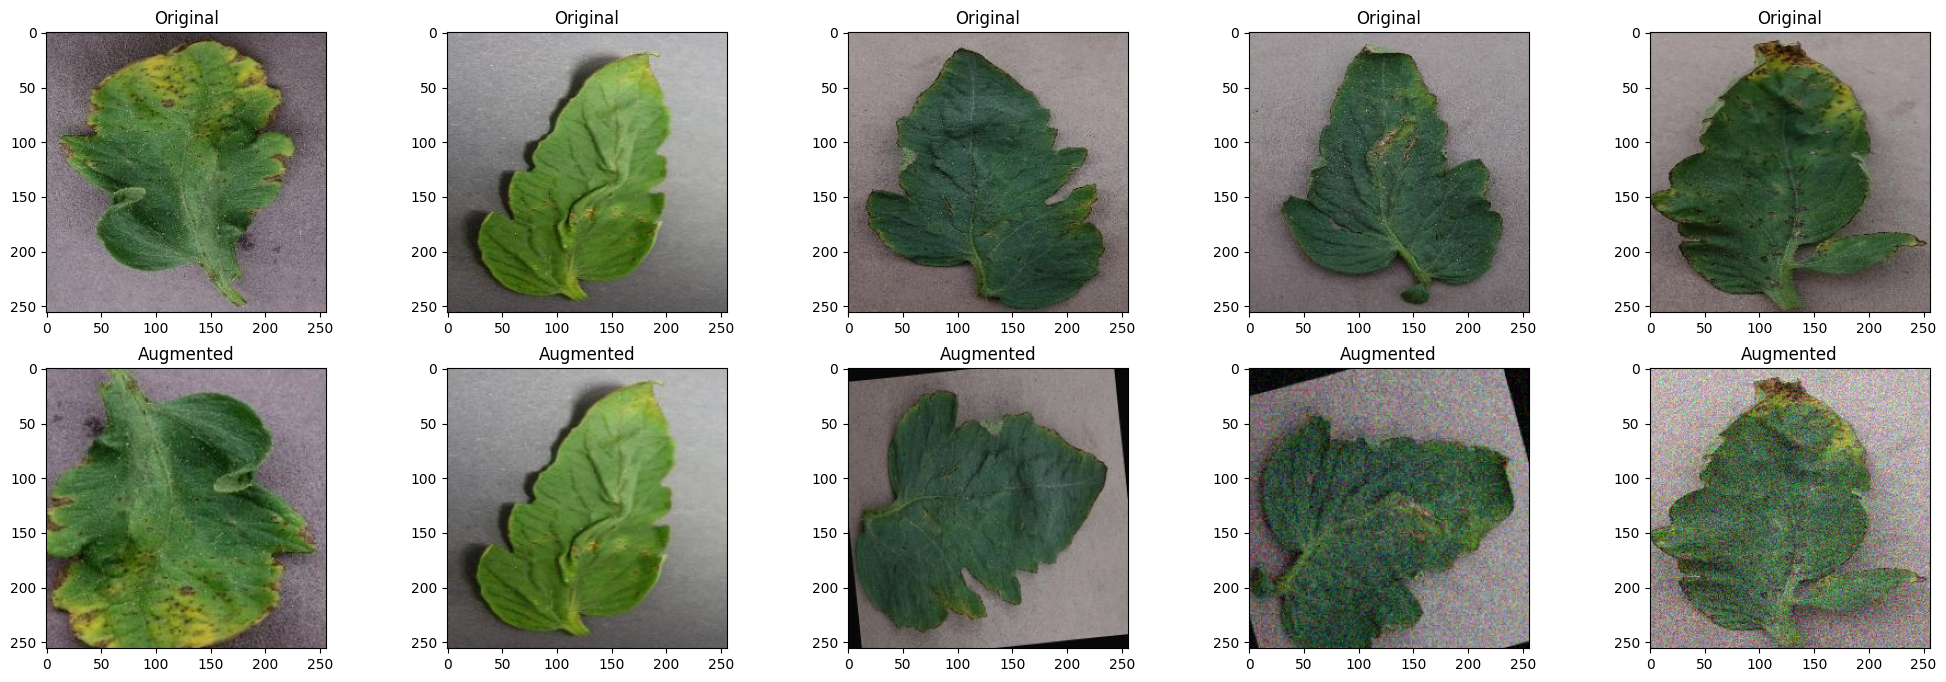

In [8]:
fig, ax = plt.subplots(2, 5, figsize=(25, 8))

for index, label in enumerate(labels):
    ax[0][index].imshow(sample_all[index])
    ax[0][index].set_title("Original")

    ax[1][index].imshow(augmented_sample_all[index])
    ax[1][index].set_title("Augmented")

In [16]:
labels

['Tomato___Bacterial_spot',
 'Tomato___healthy',
 'Tomato___Leaf_Mold',
 'Tomato___Early_blight',
 'Tomato___Late_blight']

In [ ]:
# class:
# 0 -> 'Tomato___Bacterial_spot'
# 1 -> 'Tomato___healthy'
# 2 -> 'Tomato___Leaf_Mold'
# 3 -> 'Tomato___Early_blight'
# 4 -> 'Tomato___Late_blight'
labels_class = np.concatenate([sample_labels, sample_labels])

# domain:
# 0 -> original
# 1 -> augmented
labels_domain = np.array([0] * len(sample_all) + [1] * len(augmented_sample_all))

pca = PCA(n_components=50)
X_all = np.concatenate([sample_all, augmented_sample_all], axis=0)
X_flat = X_all.reshape(len(X_all), -1).astype(np.float32) / 255.0
X_reduced = pca.fit_transform(X_flat)

In [10]:
tsne = TSNE(n_components=2, random_state=RANDOM_SEED)
X_embedded = tsne.fit_transform(X_reduced)

In [17]:
# for i in range(len(X_embedded)):
#     marker = 'o' if labels_domain[i] == 0 else 'x'
#     plt.scatter(X_embedded[i,0], X_embedded[i,1],
#                 c=[labels_class[i]], cmap='tab10', marker=marker)

/tmp/ipykernel_13652/1102078159.py:4: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[0].legend()


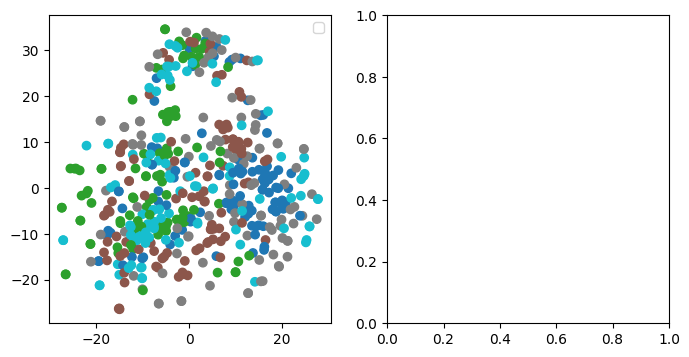

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

scatter = ax[0].scatter(X_embedded[:,0], X_embedded[:,1], c=labels_class, cmap='tab10')


ax[1].scatter(X_embedded[:,0], X_embedded[:,1], c=labels_domain)

## Phân tích PCA

## Phát hiện cạnh và phân tích đặc trưng cục bộ